# Sistema de clasificación de imágenes
El conjunto de datos se compone de fotos de perros y gatos proporcionadas como un subconjunto de fotos de uno mucho más grande de 3 millones de fotos anotadas manualmente. Estos datos se obtuvieron a través de una colaboración entre Petfinder.com y Microsoft.

El conjunto de datos se usó originalmente como un CAPTCHA, es decir, una tarea que se cree que un humano encuentra trivial, pero que una máquina no puede resolver, que se usa en sitios web para distinguir entre usuarios humanos y bots. La tarea se denominó "Asirra". Cuando se presentó "Asirra", se mencionó "que los estudios de usuarios indican que los humanos pueden resolverlo el 99,6% de las veces en menos de 30 segundos". A menos que se produzca un gran avance en la visión artificial, esperamos que los ordenadores no tengan más de 1/54.000 posibilidades de resolverlo.

En el momento en que se publicó la competencia, el resultado de última generación se logró con un SVM y se describió en un artículo de 2007 con el título "Ataques de Machine Learning contra el CAPTCHA de Asirra" (PDF) que logró una precisión de clasificación del 80%. Fue este documento el que demostró que la tarea ya no era una tarea adecuada para un CAPTCHA poco después de que se propusiera la tarea.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report

import keras
import tensorflow as tf
# from keras.models import Sequential, load_model
from keras import Sequential
import keras_tuner as kt
from keras.preprocessing import image
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Conv2D, MaxPool2D , Flatten
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.models import load_model
from keras.optimizers import Adam


In [2]:
ruta_base = "../data/dogs-vs-cats"

def contar_jpg(ruta):
    return len([f for f in os.listdir(ruta) if f.lower().endswith('.jpg')]) if os.path.isdir(ruta) else 0

for root, dirs, files in os.walk(ruta_base):
    nivel = root.replace(ruta_base, '').count(os.sep)
    sangria = '  ' * nivel
    nombre_carpeta = os.path.basename(root)
    total_jpg = contar_jpg(root)
    print(f"{sangria}{nombre_carpeta}/ ({total_jpg} imágenes)")

dogs-vs-cats/ (0 imágenes)
  test/ (0 imágenes)
    cat/ (2500 imágenes)
    dog/ (2500 imágenes)
  train/ (0 imágenes)
    cat/ (10000 imágenes)
    dog/ (10000 imágenes)


## Paso 2: Visualiza la información de entrada
El primer paso cuando nos enfrentamos a un problema de clasificación de imágenes es obtener toda la información posible a través de ellas. Por lo tanto, carga e imprime las primeras nueve fotos de perros en una sola figura. Repite lo mismo para los gatos. Puedes ver que las fotos son a color y tienen diferentes formas y tamaños.

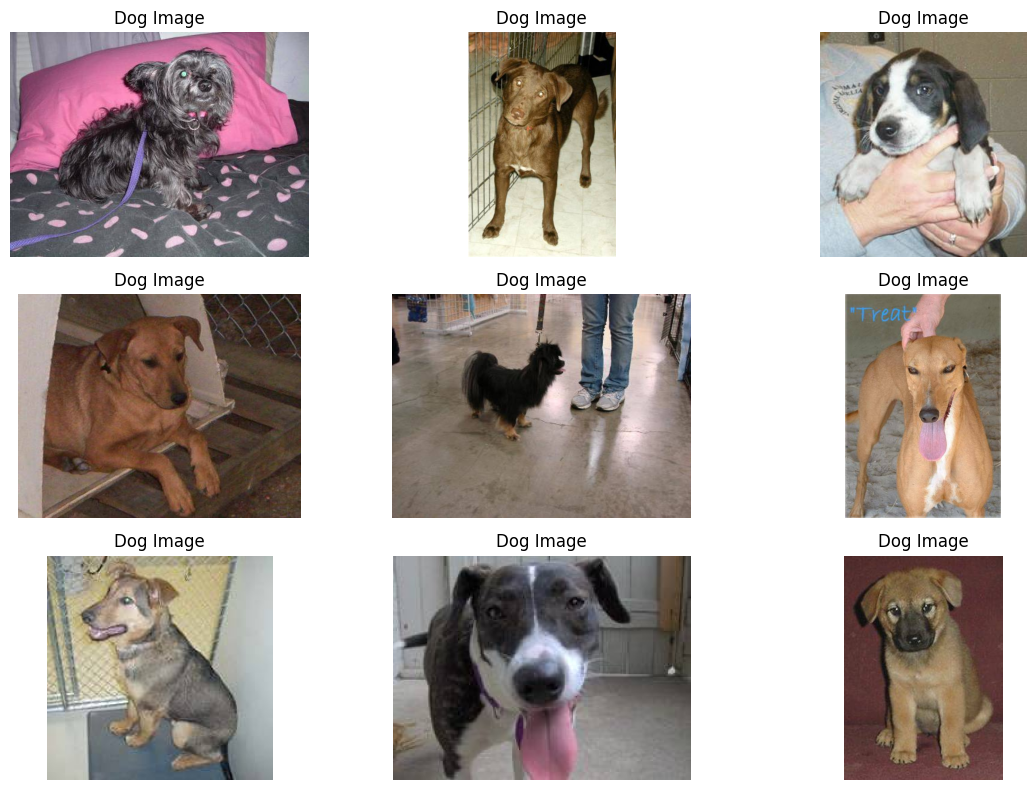

In [3]:
# Import and Check first 9 Dog Pictures

# Path to the directory containing your image data
data_dir = "../data/dogs-vs-cats/train"


# Get a list of all dog image file names
dog_subfolder = os.path.join(data_dir, "dog")

# Get a list of all dog image file names
dog_image_files = os.listdir(dog_subfolder)

# Load the first nine dog images
dog_images = []
for i in range(9):
    img_path = os.path.join(dog_subfolder, dog_image_files[i])
    img = image.load_img(img_path)  # Adjust target_size as needed
    img_array = image.img_to_array(img)
    img_array /= 255.0  # Normalize pixel values to [0, 1]
    dog_images.append(img_array)

# Create a single figure to display all nine images
plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(dog_images[i])
    plt.title('Dog Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

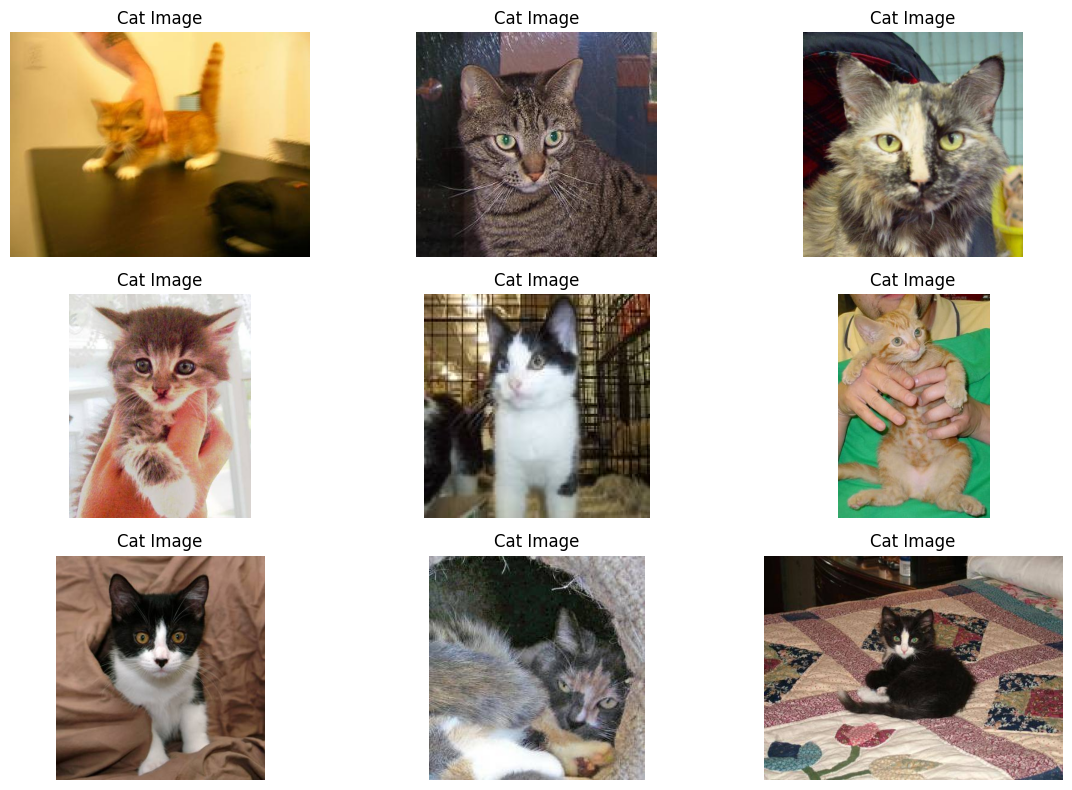

In [4]:
# Import and Check first 9 Cat Pictures

# Path to the directory containing your image data
data_dir = "../data/dogs-vs-cats/train"

# Get a list of all cat image file names
cats_subfolder = os.path.join(data_dir, "cat")

# Get a list of all Cat image file names
cats_image_files = os.listdir(cats_subfolder)

# Load the first nine cat images
cats_images = []
for i in range(min(9, len(cats_image_files))):  # Limit to available cat images
    img_path = os.path.join(cats_subfolder, cats_image_files[i])
    img = image.load_img(img_path)
    img_array = image.img_to_array(img)
    img_array /= 255.0
    cats_images.append(img_array)

# Create a single figure to display all cat images
plt.figure(figsize=(12, 8))

for i in range(len(cats_images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(cats_images[i])
    plt.title('Cat Image')
    plt.axis('off')

# Adjust Layout
plt.tight_layout()

# Show the pictures
plt.show()

In [5]:
# Poner todas las imagenes en el mismo tamaño de 200x200 pixeles.

train_dir = "../data/dogs-vs-cats/train"
test_dir = "../data/dogs-vs-cats/test"
image_size = (200, 200)
BATCH_SIZE = 32 # Valor estándar recomendado

datagentrain = ImageDataGenerator(rescale=1./255)
datagentest = ImageDataGenerator(rescale=1./255)

# Train Data Generation
train_data = datagentrain.flow_from_directory(train_dir,
                                              target_size = image_size, batch_size = BATCH_SIZE,
                                              classes = ["dog", "cat"], class_mode = 'binary')

# Test Data Generation
test_data = datagentest.flow_from_directory(test_dir,
                                            target_size = image_size,batch_size = BATCH_SIZE,
                                            classes = ["dog", "cat"], class_mode = 'binary')

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [9]:
model = Sequential()

# 1. Bloque de Extracción de Característica Principal (Principio)
# Simulación del Bloque 1
model.add(Conv2D(input_shape = (200,200,3), filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 64, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (112, 112, 64)

# 2. Bloque de Característica 1
# Simulación del Bloque 2
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 128, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (56, 56, 128)

# 3. Bloque de Característica 2
# Simulación del Bloque 3
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
model.add(Conv2D(filters = 256, kernel_size = (3,3), padding = "same", activation = "relu"))
# Eliminamos una capa Conv2D para simplificar el bloque
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (28, 28, 256)

# 4. Bloque de Característica 3
# Simulación de parte de los Bloques 4 y 5, usando menos filtros densos
model.add(Conv2D(filters = 512, kernel_size = (3,3), padding = "same", activation = "relu"))
# Eliminamos la capa Conv2D adicional para simplificar
model.add(MaxPool2D(pool_size = (2,2), strides = (2,2))) # Salida: (14, 14, 512)

# 5. Capas de Clasificación (Fin)
model.add(Flatten()) # Aplanar los datos: 14 * 14 * 512 = 100352 unidades
# Reducimos las capas densas de 4096 a un valor más pequeño, por ejemplo, 512 o 1024
model.add(Dense(units = 1024, activation = "relu"))
# Eliminamos una capa densa para simplificar
model.add(Dense(units = 2, activation = "softmax")) # Capa de salida para 2 clases

In [ ]:
# Compile the Model before Training
model.compile(loss = keras.losses.categorical_crossentropy, optimizer = Adam(learning_rate = 0.001), metrics = ["accuracy"])

In [12]:
# Train the Model
model.fit(train_data, epochs = 1)

ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 2)

In [ ]:
checkpoint = ModelCheckpoint("../models/vgg16_1.h5", monitor = "val_accuracy", verbose = 1, save_best_only = True, save_weights_only = False, mode = "auto")
early = EarlyStopping(monitor = "val_accuracy", patience = 3, verbose = 1, mode = "auto")
hist = model.fit(train_data, steps_per_epoch = 100, validation_data = test_data, validation_steps = 10, epochs = 3, callbacks = [checkpoint, early])

In [ ]:
# Check the Accuracy of the Data

# Plot the Results
plt.plot(hist.history["accuracy"])
plt.plot(hist.history["val_accuracy"])
plt.plot(hist.history["loss"])
plt.plot(hist.history["val_loss"])

# Configure the Plot Layout
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Accuracy", "Validation Accuracy", "Loss", "Validation Loss"])

# Plot
plt.show()

In [ ]:
img = image.load_img("../data/raw/test/9.jpg", target_size = (200, 200))
img = np.asarray(img)
plt.imshow(img)
img = np.expand_dims(img, axis = 0)
saved_model = load_model("../models/vgg16_1.h5")
output = saved_model.predict(img)
if output[0][0] > output[0][1]:
    print("cat")
else:
    print("dog")